In [14]:
import sys
sys.path.insert(1, '/home/bricej/MyPythonLibrary/StageM2_IVT/library/')
import domain
from domain import *
from climbas import *
import numpy as np
import xarray as xr
import pandas as pd
from netCDF4 import Dataset
from scipy import stats
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Period

In [2]:
iyear = 1960
fyear = 2025
variables = ['vimdf']
domains = ['HMA','HK','SL','TP','CH','SEH']

# TCWV & IVT Data

In [3]:
var_dict = {}

files = {'vimdf': 'vimdf_monthly_era5_1940-2025_NH_025x025.nc'}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/era5/monthly/'

for var in variables:
    var_dict[var] = {}
    var_data = xr.open_dataset(path + files[var])[var]

    var_data = var_data.rename({'valid_time': 'time'})
    var_data = var_data.rename({'longitude': 'lon'})
    var_data = var_data.rename({'latitude': 'lat'})

    if var == 'vimdf':    
        # pour alléger le dossier 
        var_data = var_data.drop_vars(['number','expver'], errors='ignore')  # les variables inutiles
        var_data.attrs = {}  # les atributs pas utiles pour les calculs
    
    var_data = var_data.sel(time=slice(str(iyear),str(fyear)))
    
    for domain in domains:
            var_dict[var][domain] = field_dom(var_data,domain)

# MONTHLY MEAN DATASETS DOMAINS

In [4]:
var_mean_dict = {}

for var in variables:
    var_mean_dict[var]={}
    print(var)
    for domain in domains:
        var_mean_dict[var][domain] = var_dict[var][domain].groupby('time.month').mean('time', skipna=True)
        var_mean_dict[var][domain] = var_mean_dict[var][domain].mean(dim=['lat','lon'], skipna=True)
        print(domain)


vimdf
HMA
HK
SL
TP
CH
SEH


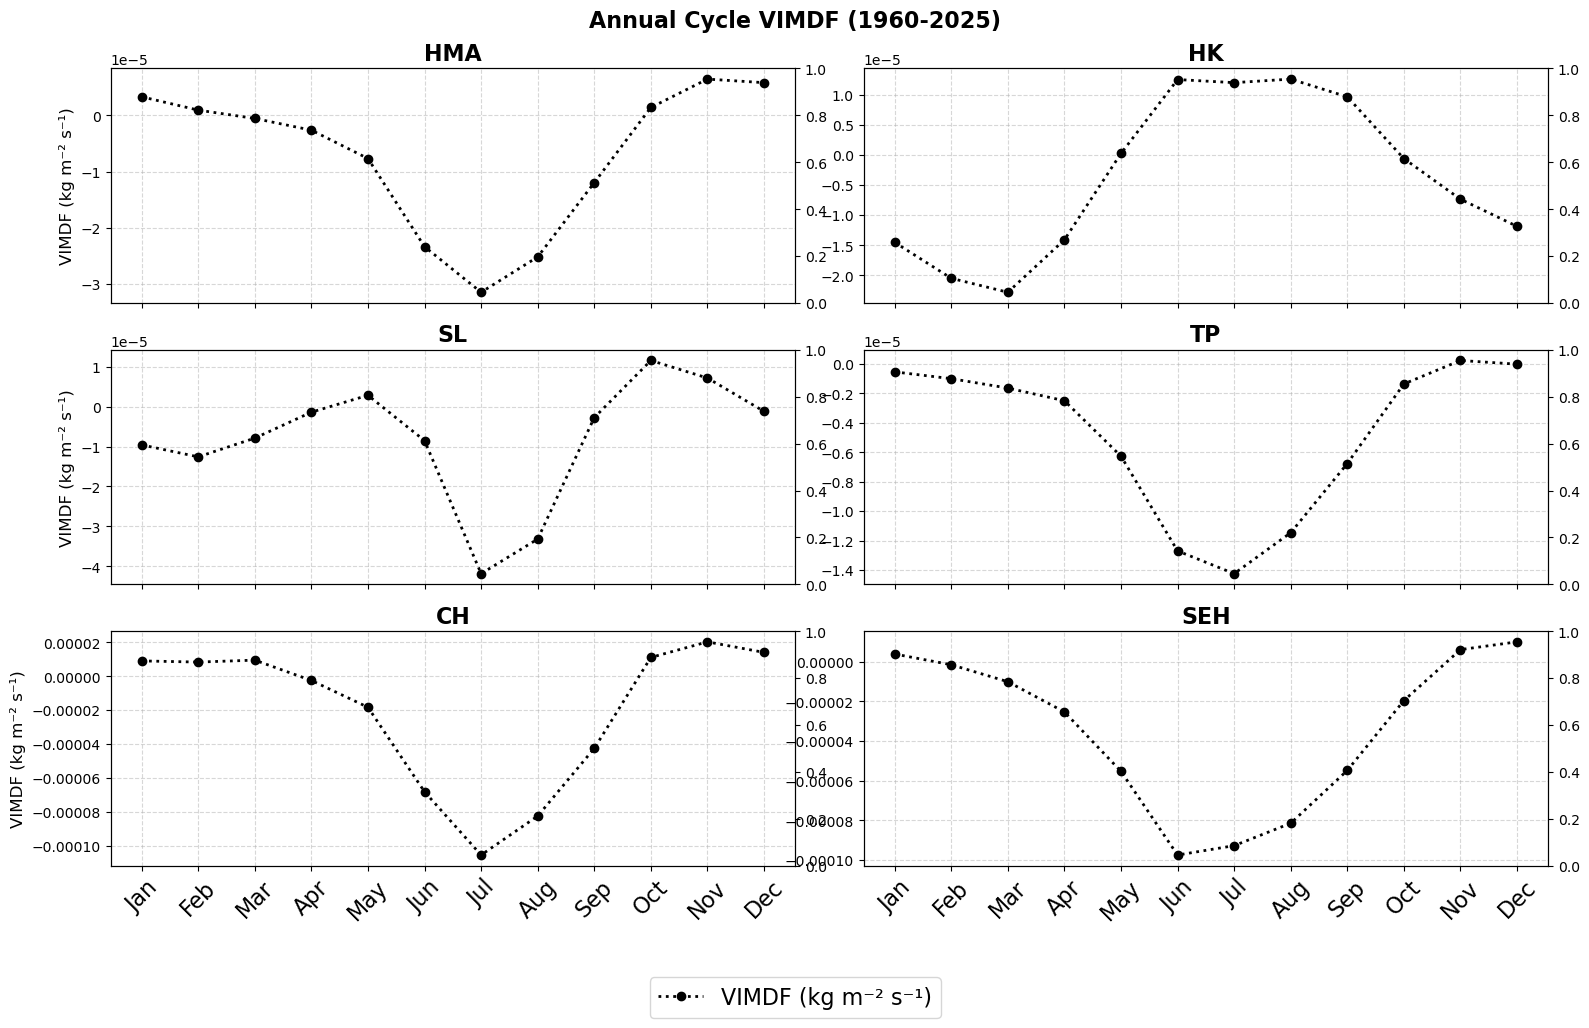

In [6]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
unite = {'vimdf': 'kg m⁻² s⁻¹'}

colors = {'vimdf': 'black'}

fig, axes = plt.subplots(3, 2, figsize=(16,10))
axes = axes.flatten()

handles_all = []
labels_all = []

for i, dom in enumerate(domains):

    ax = axes[i]
    ax2 = ax.twinx()

    # --- VIMDF
    da_tcwv = var_mean_dict['vimdf'][dom]
    l1, = ax.plot(
        da_tcwv['month'], da_tcwv.values,
        marker='o', linestyle=':', color=colors['vimdf'],
        label=f'VIMDF ({unite["vimdf"]})', linewidth=2
    )

    # récupérer légende sur la première figure
    if i == 0:
        handles_all.extend([l1])
        labels_all.extend([l1.get_label()])

    # --- reste inchangé
    ax.set_title(dom, fontsize=16, weight="bold")
    ax.set_xticks(range(1,13))

    if i in [4, 5]:
        ax.set_xticklabels(months, rotation=45, fontsize=16)
    else:
        ax.tick_params(labelbottom=False)

    if i in [0, 2, 4]:
        ax.set_ylabel('VIMDF (kg m⁻² s⁻¹)', fontsize=12)

    ax.grid(True, linestyle='--', alpha=0.5)

# --- légende
fig.legend(
    handles_all,
    labels_all,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=2,
    fontsize=16,
    frameon=True
)

fig.suptitle(f'Annual Cycle VIMDF ({iyear}-{fyear})', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.subplots_adjust(hspace=0.2, wspace=0.1)
plt.show()

# Comparing with ERA5 and CHIRPS precipitation

In [7]:
iyear = 1960
fyear = 2025
models = ['CHIRPS','ERA5']
domains = ['HMA','HK','SL','TP','CH','SEH']

In [8]:
tp_datasets = {}

files = {'CHIRPS': 'tp_HMA_1981-2025_CHIRPS.nc',
        'ERA5': 'tp_HMA_1940-2025_ERA5.nc'}

path = '/bettik/PROJECTS/pr-regional-climate/bricej/tp_datasets/'


for model in models:
    tp_datasets[model] = {}
    tp_model = xr.open_dataset(path + files[model])['tp']
    if model=='ERA5':
        tp_model=tp_model.sel(time=slice(str(iyear),str(fyear)))
    else:
            tp_model=tp_model.sel(time=slice(str(1981),str(2024)))
    for domain in domains:
        tp_datasets[model][domain] = field_dom(tp_model,domain)

In [9]:
tp_mean_dict = {}

for model in models:
    tp_mean_dict[model]={}
    print(model)
    for domain in domains:
        tp_mean_dict[model][domain] = tp_datasets[model][domain].groupby('time.month').mean('time', skipna=True)
        tp_mean_dict[model][domain] = tp_mean_dict[model][domain].mean(dim=['lat','lon'], skipna=True)
        print(domain)

CHIRPS
HMA
HK
SL
TP
CH
SEH
ERA5
HMA
HK
SL
TP
CH
SEH


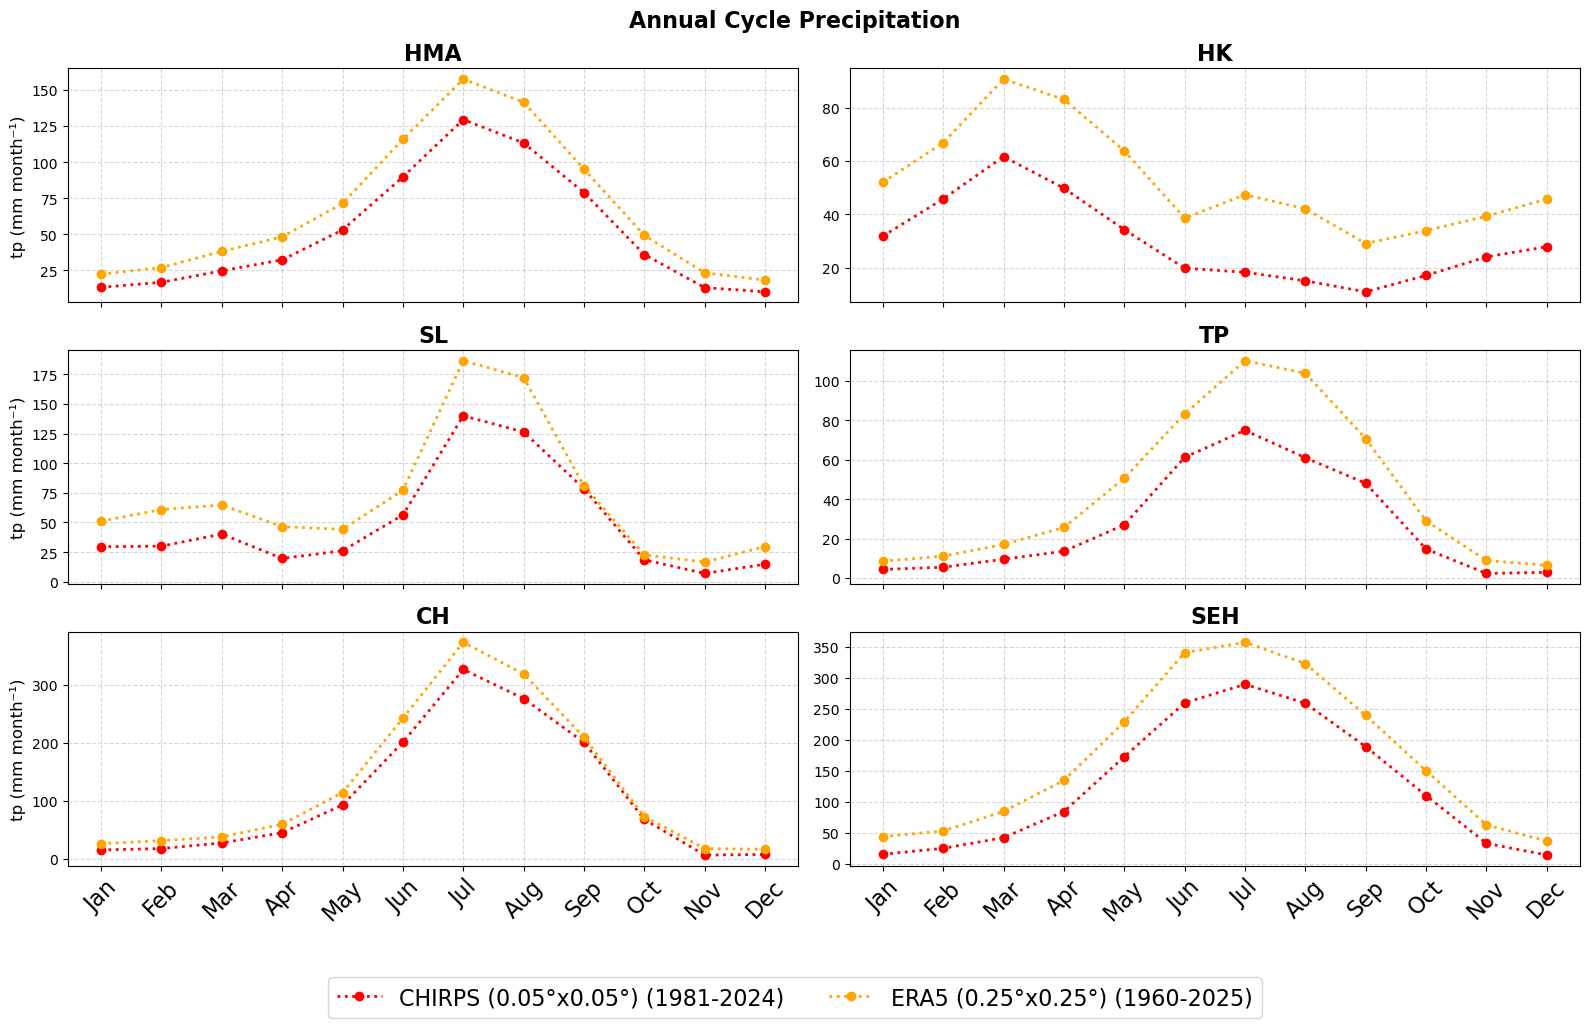

In [10]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
resolutions = {'CHIRPS': '0.05°x0.05°',
               'ERA5': '0.25°x0.25°'}
period = {'CHIRPS': '1981-2024',
               'ERA5': '1960-2025'}
colors = {'CHIRPS': 'red',
          'ERA5': 'orange'}

fig, axes = plt.subplots(3, 2, figsize=(16,10))
axes = axes.flatten()

for i, dom in enumerate(domains):

    ax = axes[i]

    for model in models:
        da = tp_mean_dict[model][dom]
        ax.plot(da['month'], da.values, marker='o', linestyle=':', color=colors[model], label=f'{model} ({resolutions[model]}) ({period[model]})', linewidth=2)

    ax.set_title(dom, fontsize=16, weight="bold")
    ax.set_xticks(range(1,13))
    
    if i in [0, 2, 4]:  # colonne gauche
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [4, 5]:  # ligne du bas
        ax.set_xticklabels(months, rotation=45, fontsize=16)
    if i in [0,1,2,3]:
        ax.tick_params(labelbottom=False)
    
    ax.grid(True, linestyle='--', alpha=0.5)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)
fig.suptitle(f'Annual Cycle Precipitation', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.show()

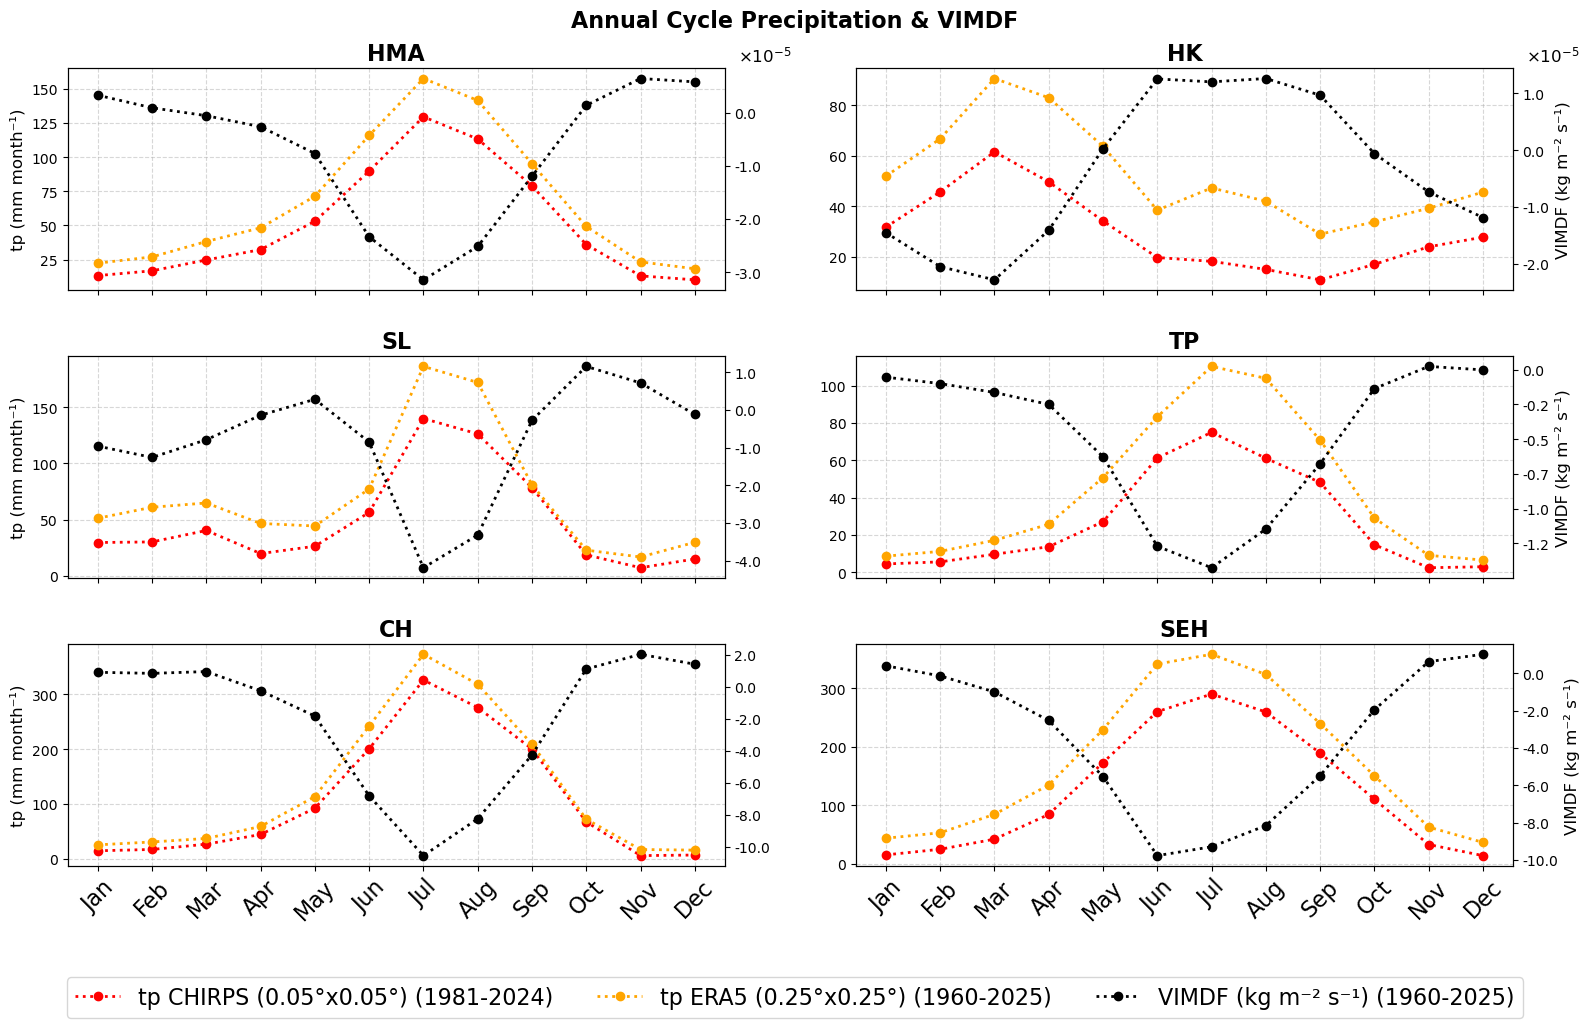

In [18]:
fig, axes = plt.subplots(3, 2, figsize=(16,10))
axes = axes.flatten()

handles_all = []
labels_all = []

for i, dom in enumerate(domains):

    ax = axes[i]
    ax2 = ax.twinx()  # axe droit

    # --- PRECIP (axe gauche)
    for model in models:
        da = tp_mean_dict[model][dom]
        l, = ax.plot(
            da['month'], da.values,
            marker='o', linestyle=':',
            color=colors[model],
            label=f'tp {model} ({resolutions[model]}) ({period[model]})',
            linewidth=2
        )

        # stocker une seule fois
        if i == 0:
            handles_all.append(l)
            labels_all.append(l.get_label())

    # --- VIMDF (axe droit)
    da_tcwv = var_mean_dict['vimdf'][dom]
    l_tcwv, = ax2.plot(
        da_tcwv['month'], da_tcwv.values,
        marker='o', linestyle=':',
        color='black',
        label=f'VIMDF (kg m⁻² s⁻¹) ({period[model]})',
        linewidth=2
    )

    # forcer l'écriture avec virgule au bon endroit
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e-5:.1f}"))
    ax2.yaxis.offsetText.set_visible(False)

    if i in [0,1]:
        ax2.text(
        1.02, 1.02, r'$\times 10^{-5}$',
        transform=ax2.transAxes,
        fontsize=12,
        ha='left',
        va='bottom')

    if i == 0:
        handles_all.append(l_tcwv)
        labels_all.append(l_tcwv.get_label())

    # --- TITRES
    ax.set_title(dom, fontsize=16, weight="bold")
    ax.set_xticks(range(1,13))

    # --- X ticks
    if i in [4, 5]:
        ax.set_xticklabels(months, rotation=45, fontsize=16)
    else:
        ax.tick_params(labelbottom=False)

    # --- Y labels
    if i in [0, 2, 4]:
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [1, 3, 5]:
        ax2.set_ylabel('VIMDF (kg m⁻² s⁻¹)', fontsize=12)

    ax.grid(True, linestyle='--', alpha=0.5)

# --- LEGENDE
fig.legend(
    handles_all,
    labels_all,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)

fig.suptitle('Annual Cycle Precipitation & VIMDF', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.subplots_adjust(hspace=0.3, wspace=0.2)

plt.show()

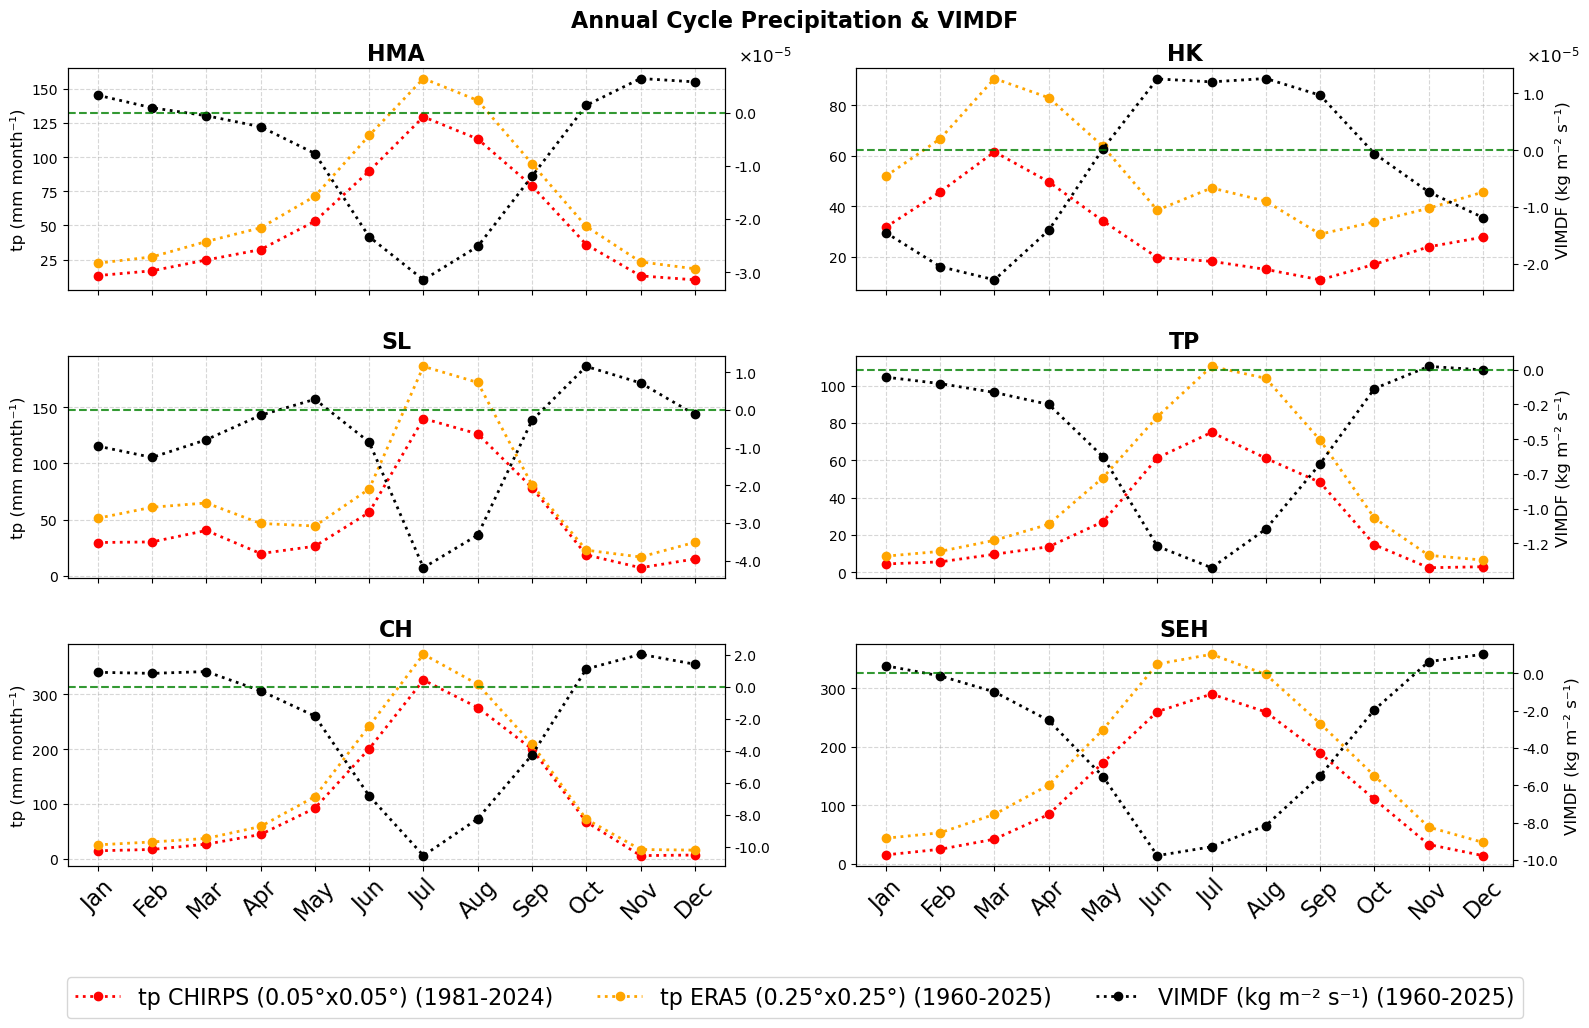

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(16,10))
axes = axes.flatten()

handles_all = []
labels_all = []

for i, dom in enumerate(domains):

    ax = axes[i]
    ax2 = ax.twinx()  # axe droit

    # --- PRECIP (axe gauche)
    for model in models:
        da = tp_mean_dict[model][dom]
        l, = ax.plot(
            da['month'], da.values,
            marker='o', linestyle=':',
            color=colors[model],
            label=f'tp {model} ({resolutions[model]}) ({period[model]})',
            linewidth=2
        )

        # stocker une seule fois
        if i == 0:
            handles_all.append(l)
            labels_all.append(l.get_label())

    # --- VIMDF (axe droit)
    da_tcwv = var_mean_dict['vimdf'][dom]
    l_tcwv, = ax2.plot(
        da_tcwv['month'], da_tcwv.values,
        marker='o', linestyle=':',
        color='black',
        label=f'VIMDF (kg m⁻² s⁻¹) ({period[model]})',
        linewidth=2
    )

    # ligne horizontale à 0 pour VIMDF
    ax2.axhline(
        y=0,
        color='green',
        linestyle='--',
        linewidth=1.5,
        alpha=0.8
    )

    # forcer l'écriture avec virgule au bon endroit
    ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e-5:.1f}"))
    ax2.yaxis.offsetText.set_visible(False)

    if i in [0,1]:
        ax2.text(
        1.02, 1.02, r'$\times 10^{-5}$',
        transform=ax2.transAxes,
        fontsize=12,
        ha='left',
        va='bottom')
    
    if i == 0:
        handles_all.append(l_tcwv)
        labels_all.append(l_tcwv.get_label())

    # --- TITRES
    ax.set_title(dom, fontsize=16, weight="bold")
    ax.set_xticks(range(1,13))

    # --- X ticks
    if i in [4, 5]:
        ax.set_xticklabels(months, rotation=45, fontsize=16)
    else:
        ax.tick_params(labelbottom=False)

    # --- Y labels
    if i in [0, 2, 4]:
        ax.set_ylabel('tp (mm month⁻¹)', fontsize=12)
    if i in [1, 3, 5]:
        ax2.set_ylabel('VIMDF (kg m⁻² s⁻¹)', fontsize=12)

    ax.grid(True, linestyle='--', alpha=0.5)

# --- LEGENDE
fig.legend(
    handles_all,
    labels_all,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.04),
    ncol=3,
    fontsize=16,
    frameon=True
)

fig.suptitle('Annual Cycle Precipitation & VIMDF', fontsize=16, weight='bold')

plt.tight_layout(rect=[0,0.05,1,1])
plt.subplots_adjust(hspace=0.3, wspace=0.2)

plt.show()